In [ ]:
import numpy as np
import sys
from datetime import datetime
from pathlib import Path
import pandas as pd 

In [ ]:
sys.path.insert(0, str(Pathwd().parent / "src"))

from modifiers.data.preprocessor import StrokePreprocessor
from modifiers.data.loader import StrokeDataLoader
from modifiers.data.augmenter import StrokeAugmenter
from modifiers.features.geometric import GeometricFeatureExtractor
from modifiers.features.renderer import StrokeRenderer
from modifiers.utils.config import load_config
from modifiers.utils.logging import setup_logging, get_logger

In [8]:
loader = StrokeDataLoader(data_dir= r"C:\Users\huybh\onedrive\documents\onepen\data\raw")

In [9]:
raw_data = loader.load()

In [12]:
df = pd.DataFrame(raw_data)

In [13]:
df.shape

(4633, 4)

🌀 Augmentation 1/6 | Angle: 1.44°, Shear: (0.007319929702695738, -0.050803567487654536), Scale: (0.99134145845023, 0.9699446252653964)


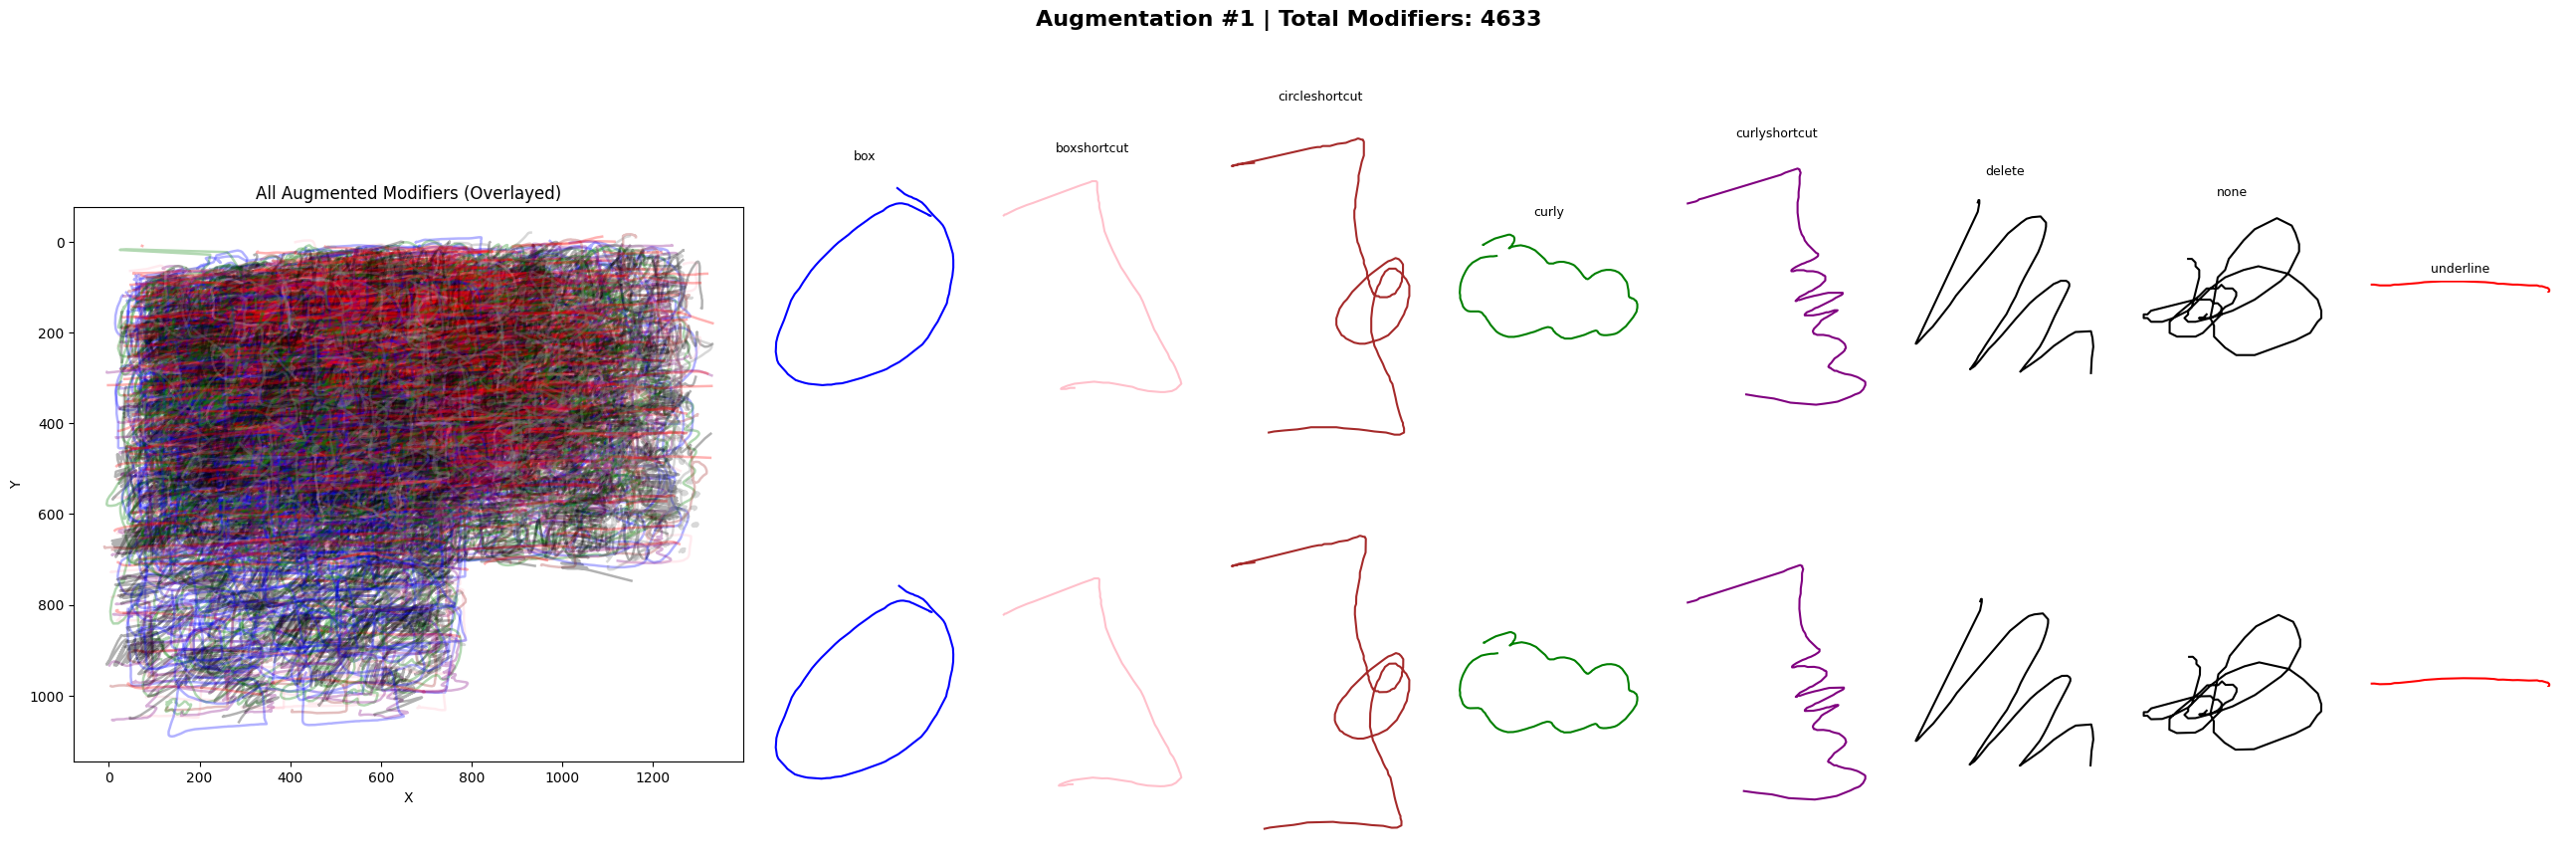

🌀 Augmentation 2/6 | Angle: -2.62°, Shear: (-0.19207854887150144, -0.06814779535702116), Scale: (0.9609700247785757, 0.9138213890573489)


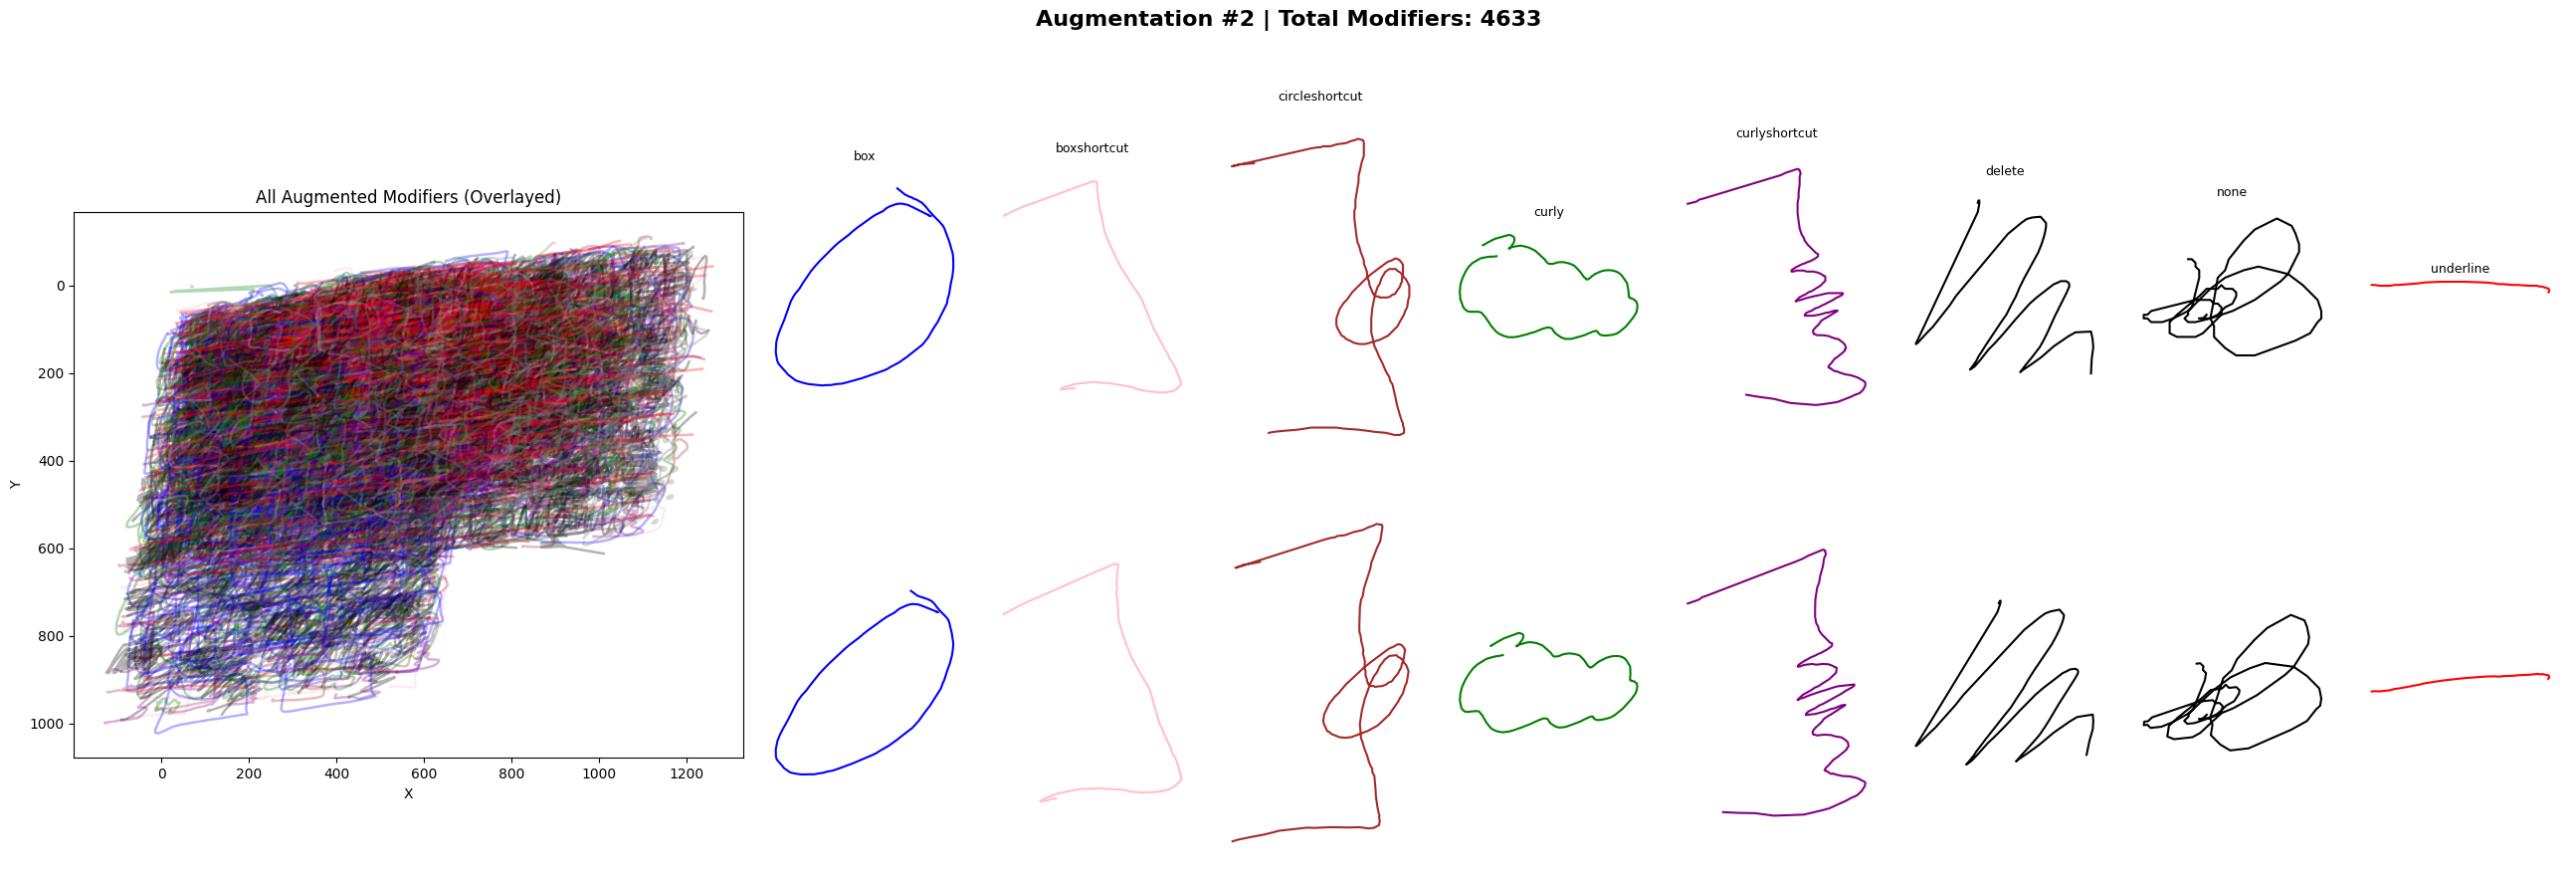

🌀 Augmentation 3/6 | Angle: -5.26°, Shear: (-0.19246254207885866, -0.06207418464729069), Scale: (1.0042269779291864, 0.9058745023170532)


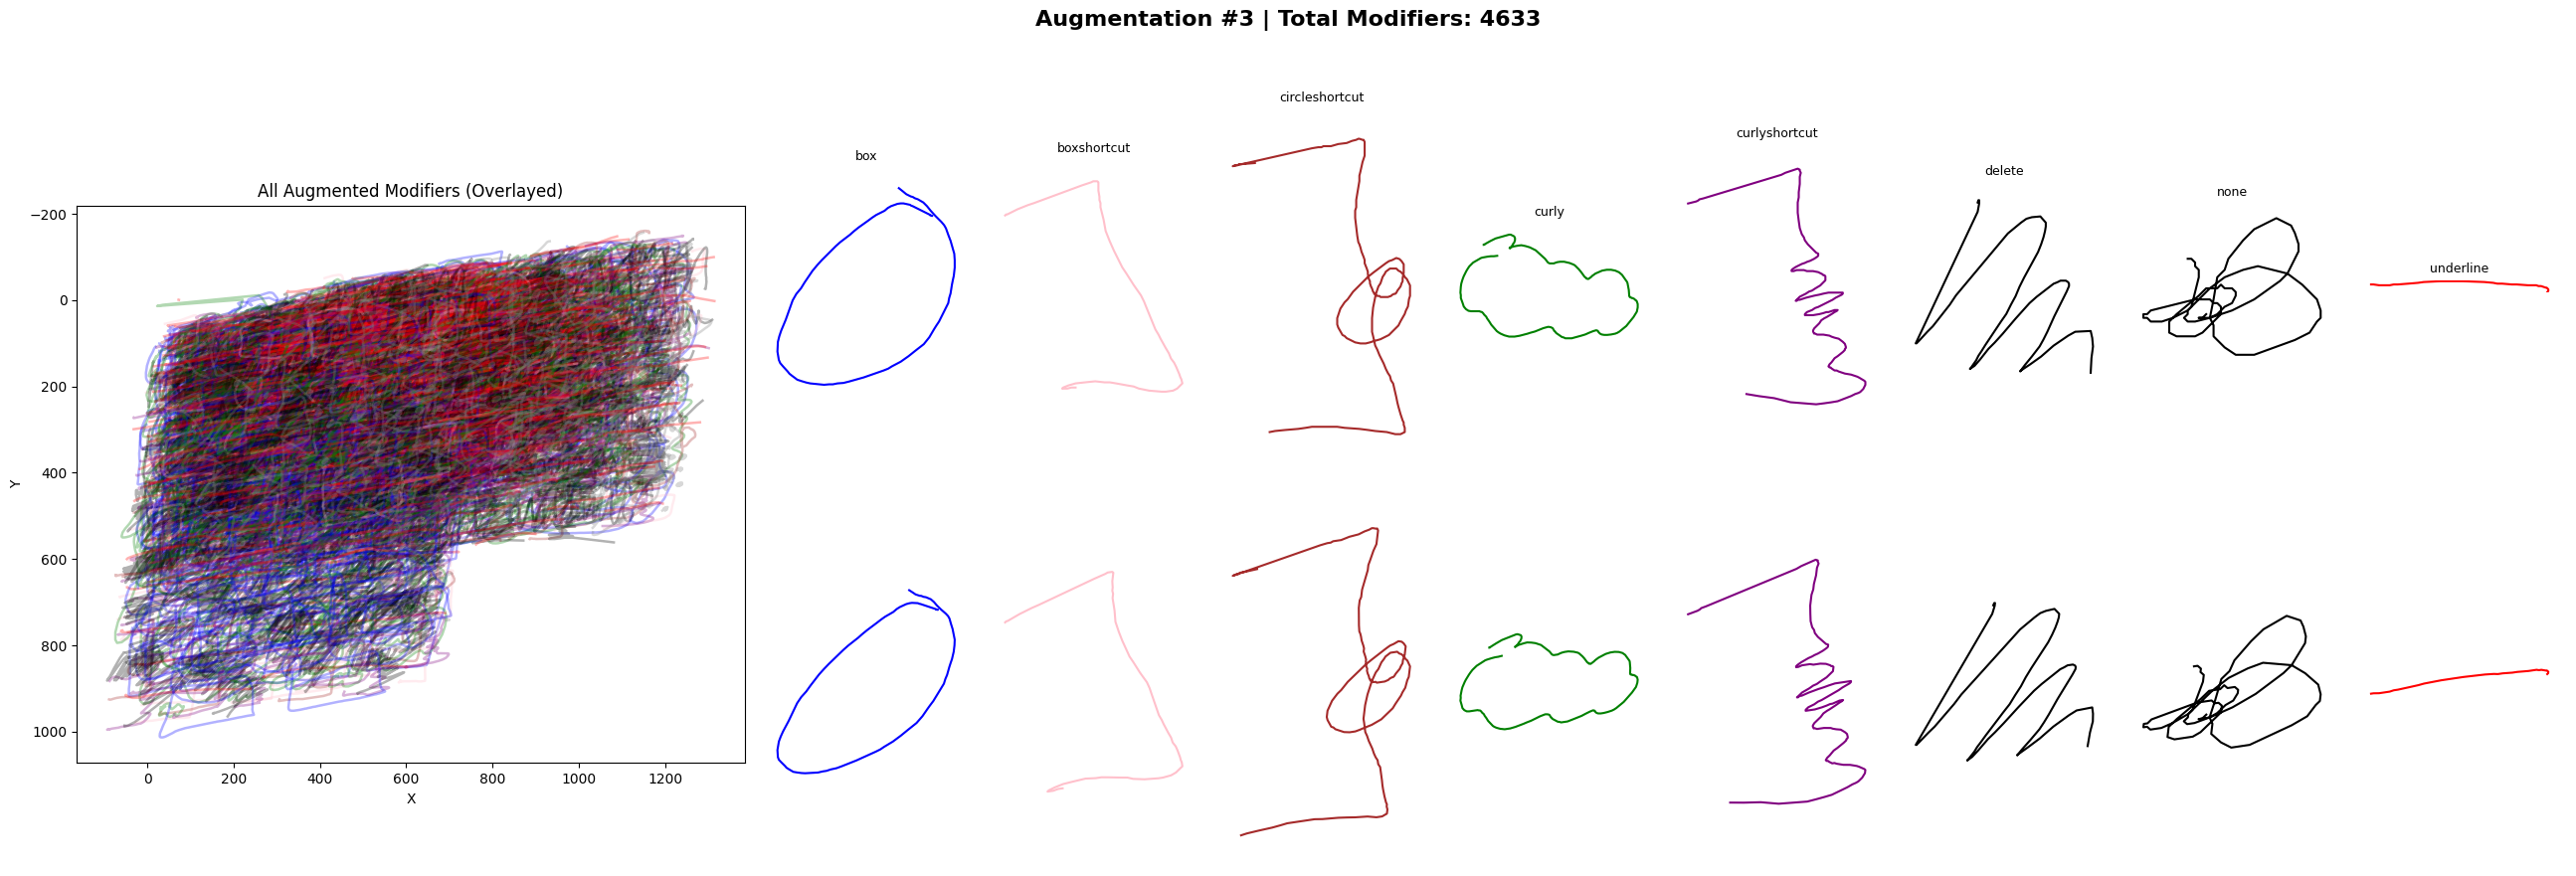

🌀 Augmentation 4/6 | Angle: -1.61°, Shear: (-0.08764617682694405, -0.022653158921443123), Scale: (0.9375280663436785, 1.0581727636756586)


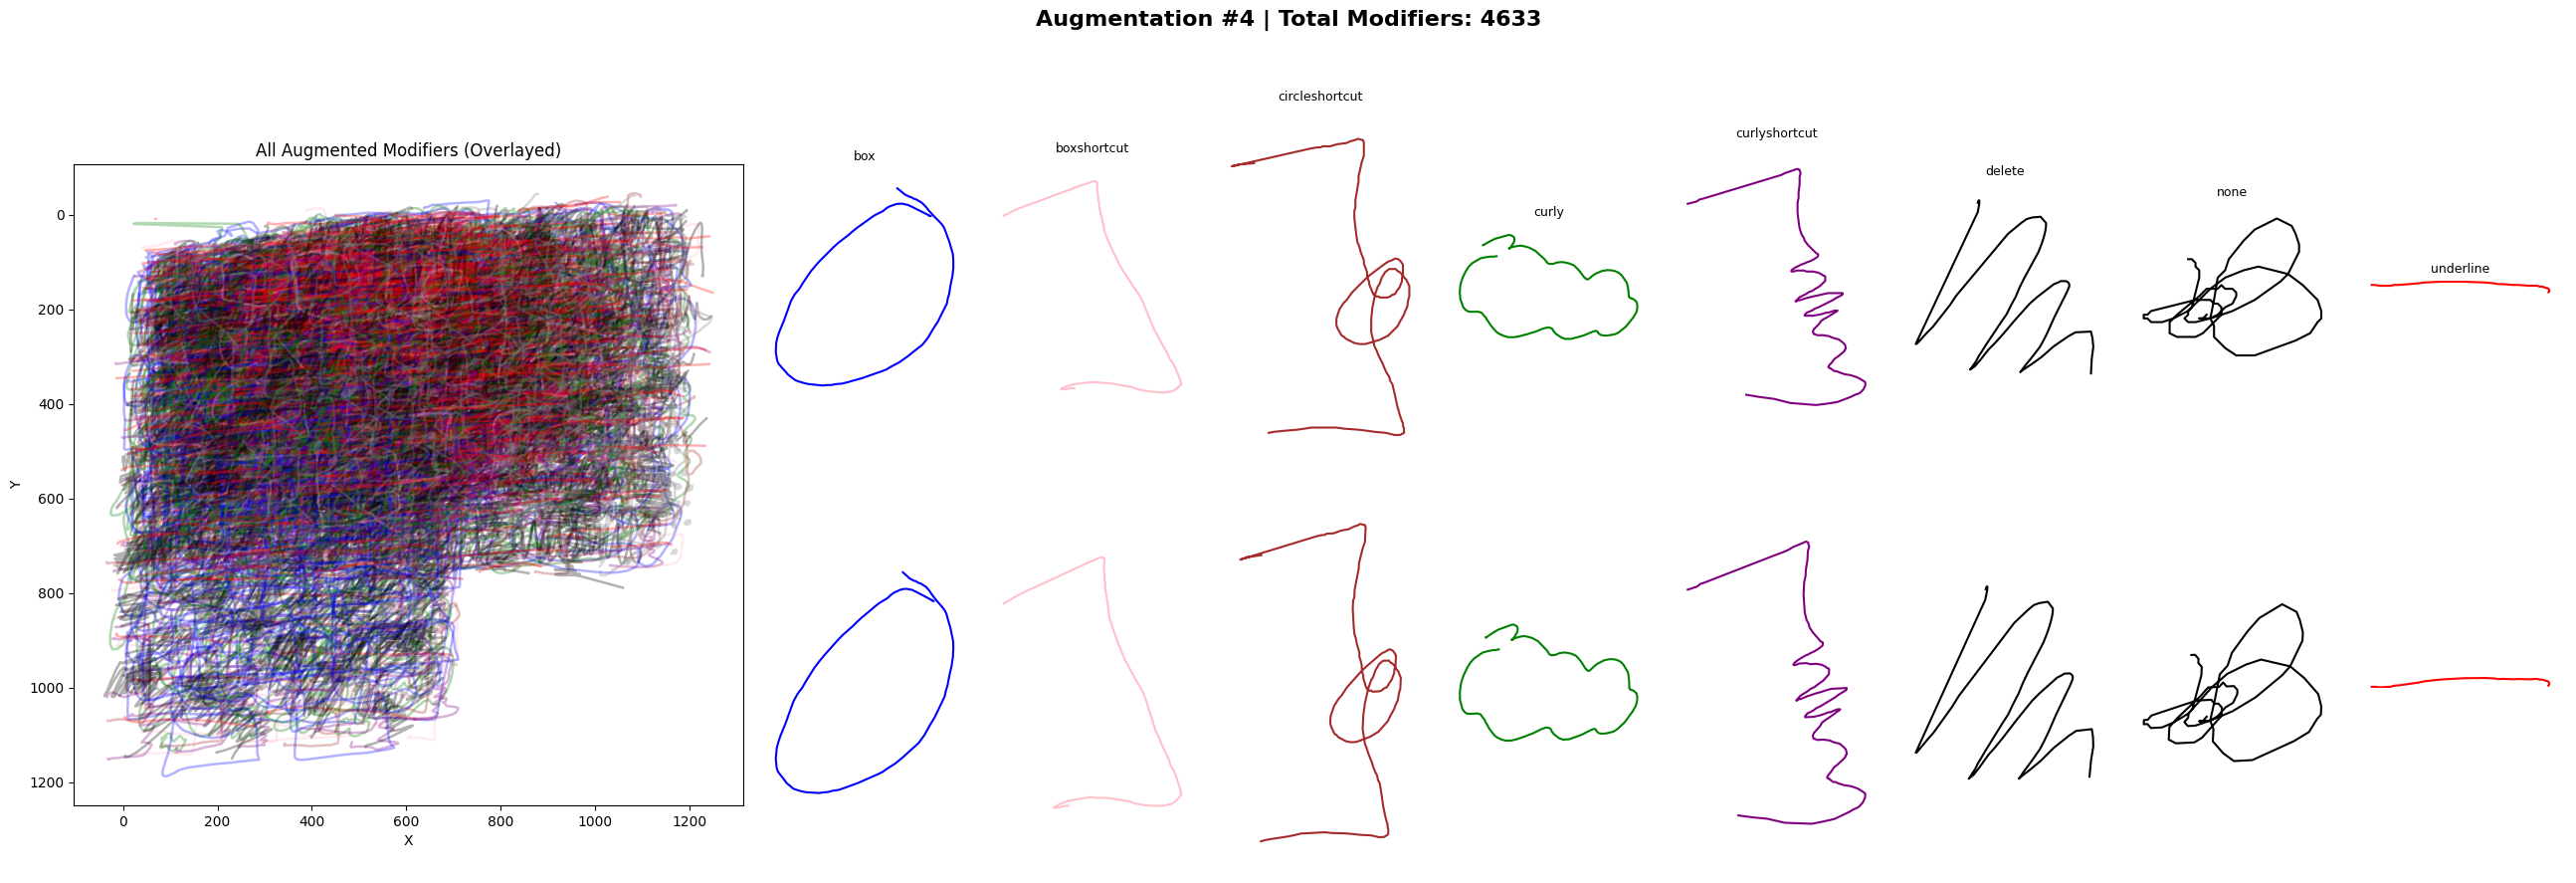

🌀 Augmentation 5/6 | Angle: -5.45°, Shear: (0.16497889916808817, 0.018254558359062825), Scale: (1.0860075210286242, 1.0985751062445879)


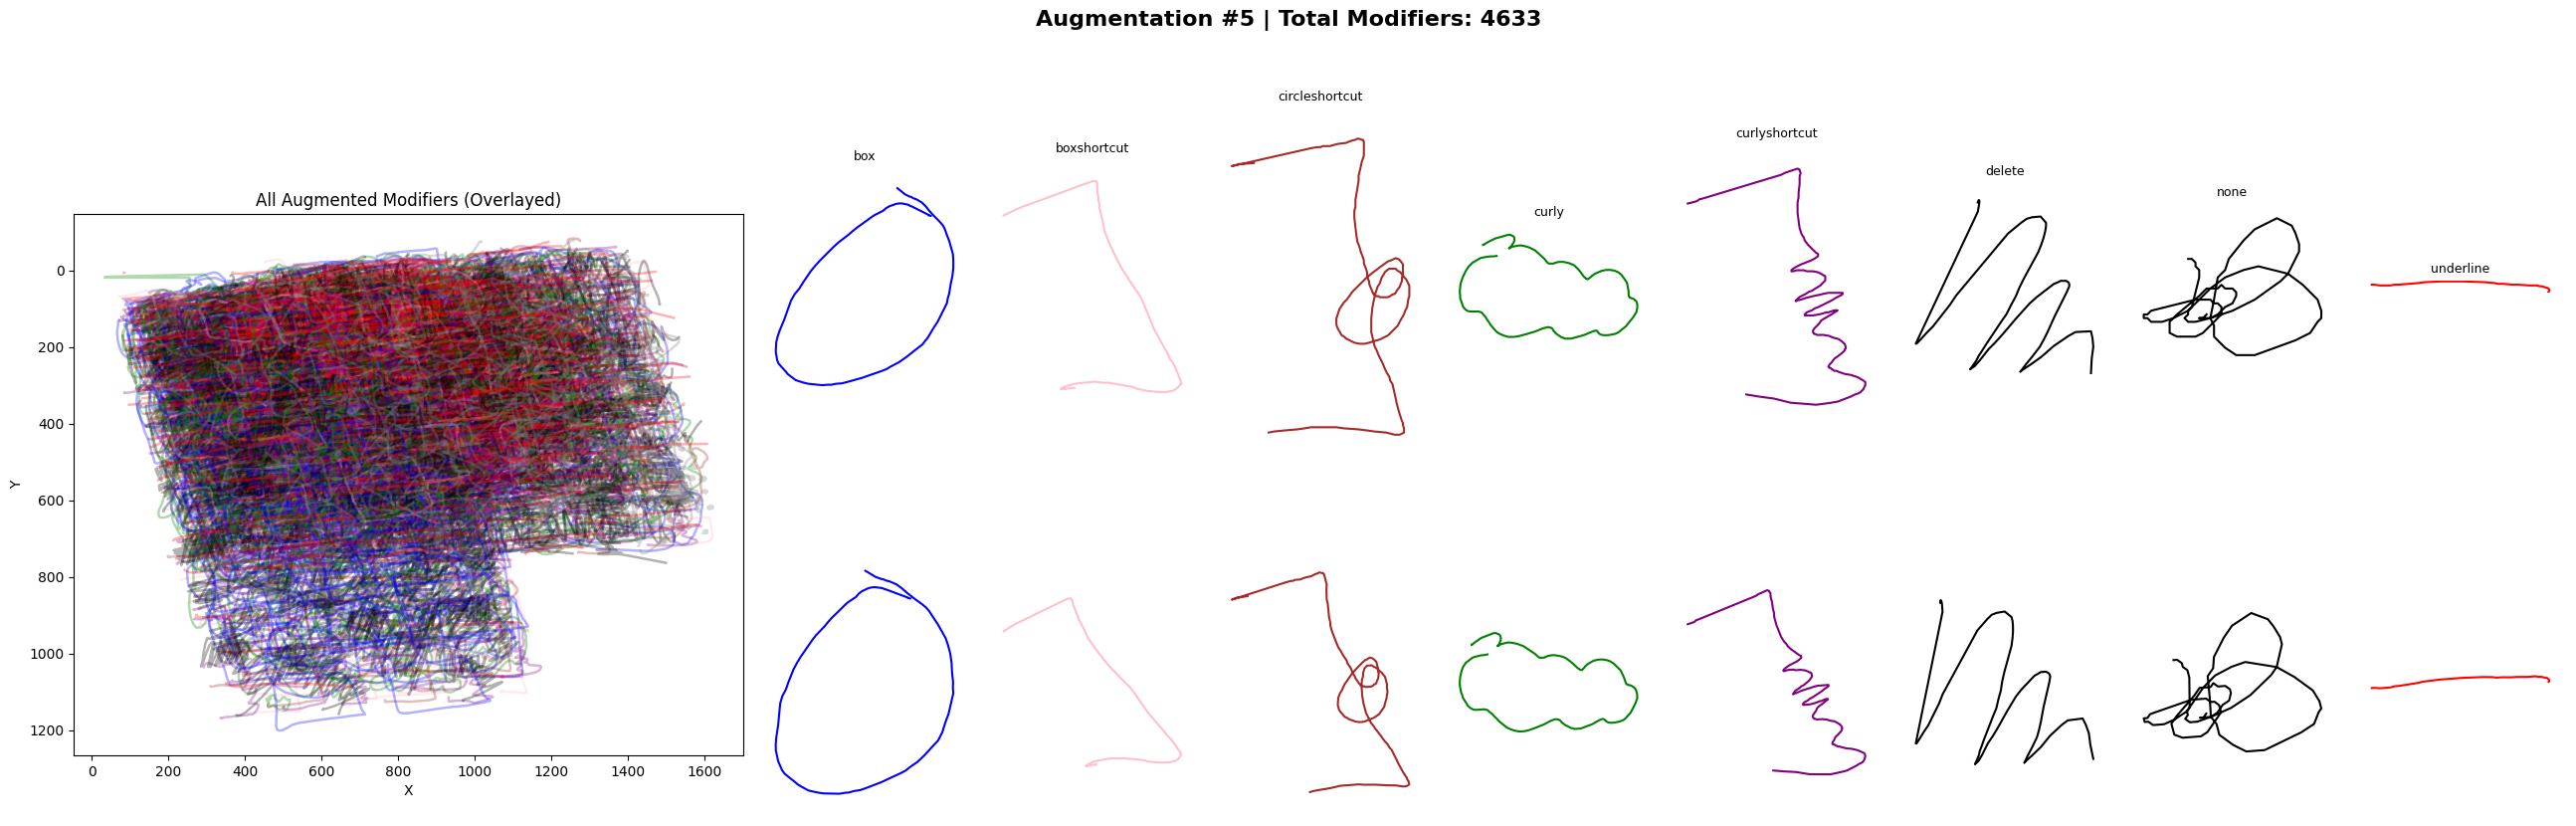

🌀 Augmentation 6/6 | Angle: 0.93°, Shear: (-0.10913614845471686, 0.05546779543760019), Scale: (1.0543020914377275, 1.0021257876369825)


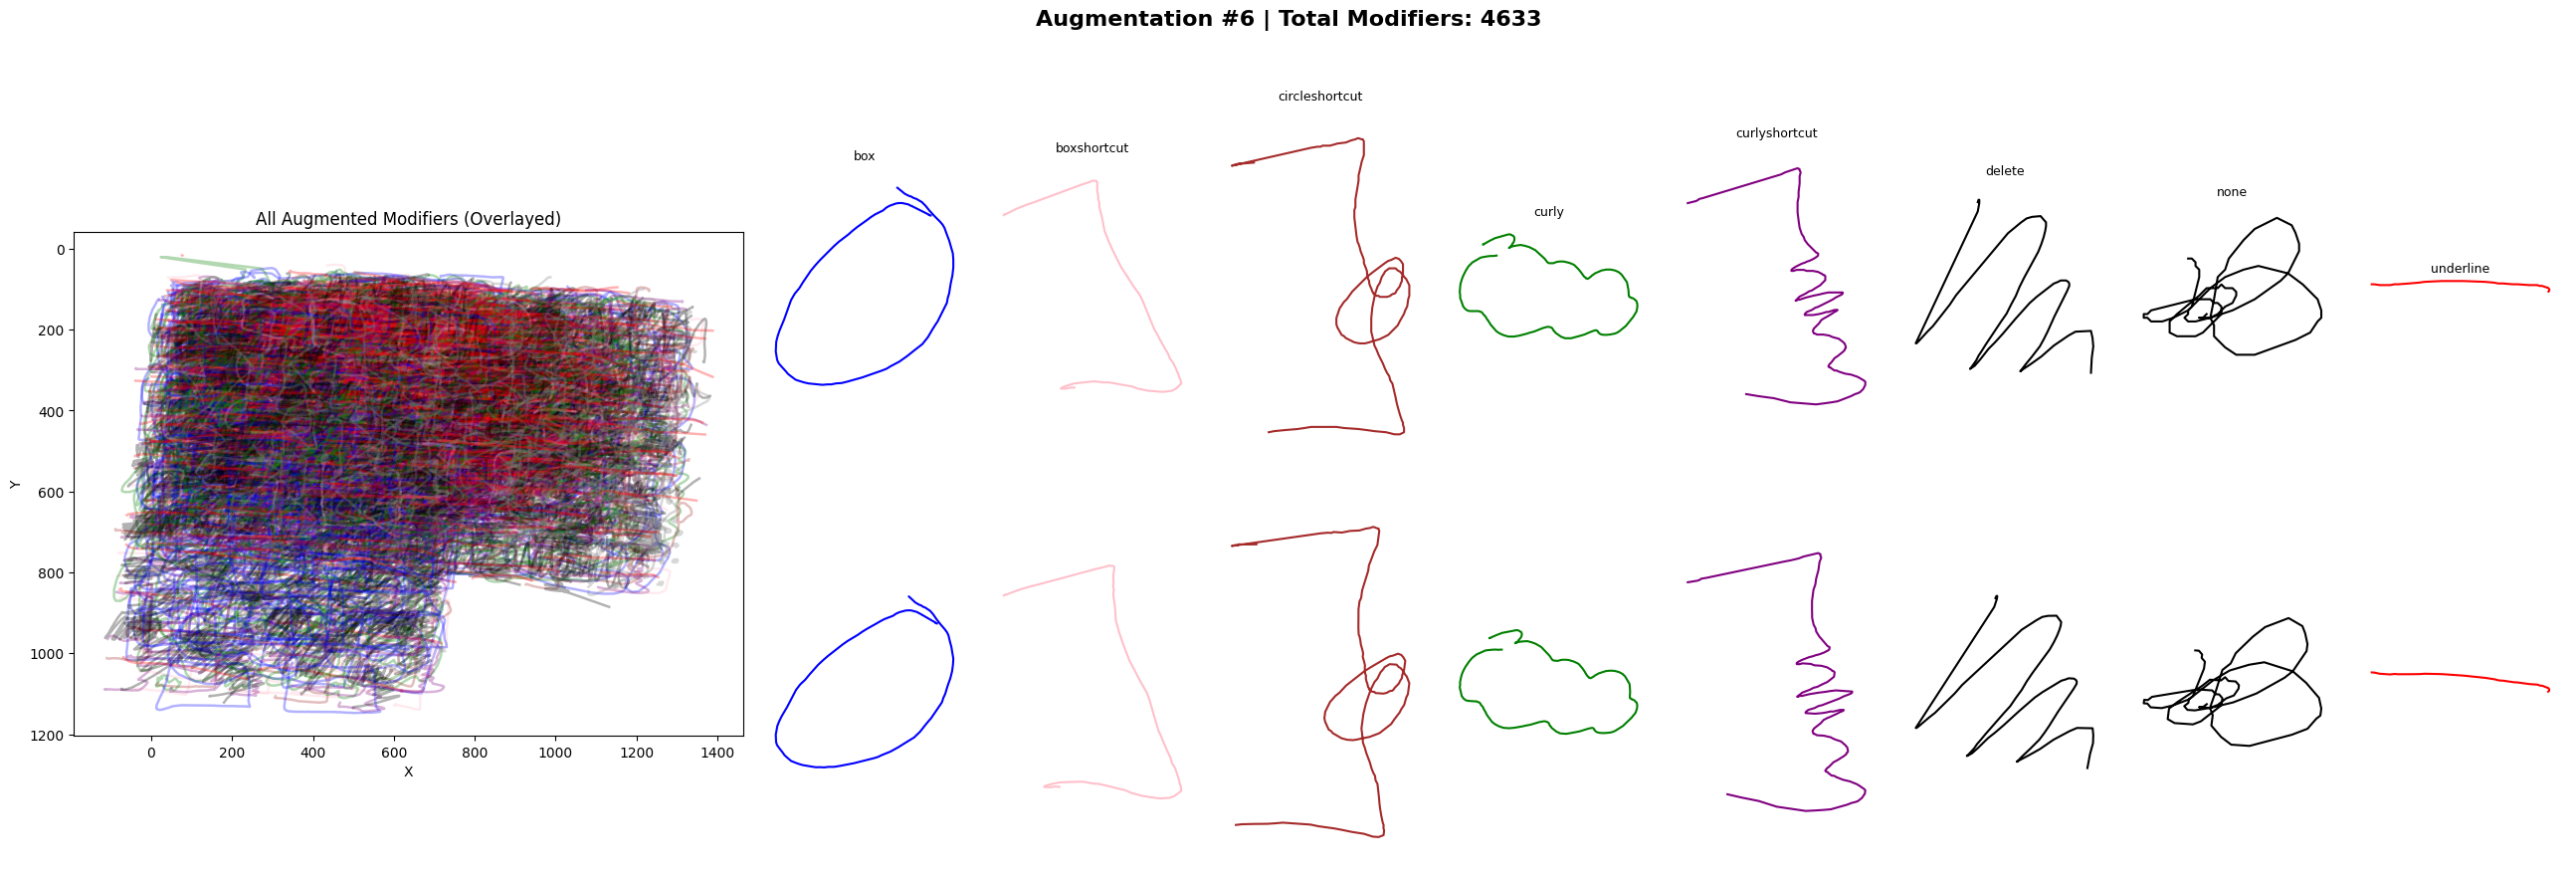


✅ Augmentation complete: 6 groups generated.
Number of augmented groups: 6


In [15]:
import json
import random
import matplotlib.pyplot as plt
import numpy as np


def augment_stroke(stroke, angle, shear, scale):
    """
    Apply shear (x & y), anisotropic scale, and rotation to a single stroke.
    - stroke: list of {"x", "y", "p"?}
    - angle: degrees
    - shear: (shear_x, shear_y)
    - scale: (scale_x, scale_y)
    """
    if not stroke or not isinstance(stroke, list):
        return []

    shear_x, shear_y = shear
    scale_x, scale_y = scale

    rad = np.radians(angle)
    cos_a, sin_a = np.cos(rad), np.sin(rad)

    transformed = []
    for pt in stroke:
        x = pt["x"]
        y = pt["y"]

        # --- Shear ---
        x_sheared = x + shear_x * y
        y_sheared = y + shear_y * x

        # --- Scale ---
        x_scaled = x_sheared * scale_x
        y_scaled = y_sheared * scale_y

        # --- Rotate ---
        x_new = cos_a * x_scaled - sin_a * y_scaled
        y_new = sin_a * x_scaled + cos_a * y_scaled

        transformed.append({
            "x": x_new,
            "y": y_new,
            "p": pt.get("p", 0)
        })

    return transformed


def augment_data(merged_data, augment_count=4):
    """
    merged_data can be:
      - a dict: {"modifiers": [...]}
      - or a plain list: [...]
    Returns list of augmented groups; each group is list of modifiers.
    """
    # Normalize structure
    if isinstance(merged_data, dict):
        original_modifiers = merged_data.get("modifiers", [])
    else:
        original_modifiers = merged_data

    all_augmented_groups = []

    for i in range(augment_count):
        angle = random.uniform(-6, 6)
        shear = (random.uniform(-0.2, 0.2), random.uniform(-0.1, 0.1))
        scale = (random.uniform(0.9, 1.1), random.uniform(0.9, 1.1))

        augmented_modifiers = []
        for mod in original_modifiers:
            stroke = mod.get("stroke", [])
            new_stroke = augment_stroke(stroke, angle, shear, scale)

            augmented_modifiers.append({
                "type": mod.get("type", "none"),
                "stroke": new_stroke
            })

        print(
            f"🌀 Augmentation {i+1}/{augment_count} | "
            f"Angle: {angle:.2f}°, Shear: {shear}, Scale: {scale}"
        )

        plot_augmented_batch(original_modifiers, augmented_modifiers, batch_idx=i+1)
        all_augmented_groups.append(augmented_modifiers)

    print(f"\n✅ Augmentation complete: {len(all_augmented_groups)} groups generated.")
    return all_augmented_groups

def plot_augmented_batch(original_modifiers, augmented_modifiers, batch_idx=1):
    colors = {
        'box': 'blue',
        'curly': 'green',
        'underline': 'red',
        'delete': 'black',
        'boxshortcut': 'pink',
        'curlyshortcut': 'purple',
        'circleshortcut': 'brown',
        'nonedaucham': '#808080',
        'nonedaulon': '#FFA500',
        'nonedaunhon': '#4682B4'   # steel blue
    }

    # All types present in this augmented batch
    all_types = sorted(set(m.get('type', 'none') for m in augmented_modifiers))
    num_types = min(len(all_types), 10)  # show up to 10
    total_cols = 3 + num_types  # left 1/3 + right grid columns

    fig = plt.figure(figsize=(26, 9))
    fig.suptitle(
        f"Augmentation #{batch_idx} | Total Modifiers: {len(augmented_modifiers)}",
        fontsize=16, fontweight="bold"
    )

    # ==== LEFT: Overview of all augmented strokes ====
    ax_overview = plt.subplot2grid((1, total_cols), (0, 0), colspan=3)
    ax_overview.set_title("All Augmented Modifiers (Overlayed)", fontsize=12)

    for m in augmented_modifiers:
        stroke = m.get("stroke", [])
        if not stroke:
            continue
        x = [p["x"] for p in stroke]
        y = [p["y"] for p in stroke]
        if len(x) == 0:
            continue
        ax_overview.plot(
            x, y,
            color=colors.get(m.get("type", "none"), 'gray'),
            alpha=0.3,
            linewidth=1.8
        )

    ax_overview.invert_yaxis()
    ax_overview.set_aspect('equal')
    ax_overview.set_xlabel("X")
    ax_overview.set_ylabel("Y")

    # ==== RIGHT: Grid (Original vs Augmented) ====
    sample_types = all_types[:num_types]
    margin = 0.1

    for col, t in enumerate(sample_types):
        orig = next((m for m in original_modifiers if m.get('type') == t), None)
        aug = next((m for m in augmented_modifiers if m.get('type') == t), None)
        if not orig or not aug:
            continue

        # --- Top: Original ---
        ax_orig = plt.subplot2grid((2, total_cols), (0, 3 + col))
        stroke = orig.get("stroke", [])
        if stroke:
            x = [p["x"] for p in stroke]
            y = [p["y"] for p in stroke]
            if x and y:
                ax_orig.plot(x, y, color=colors.get(t, 'black'))
                ax_orig.invert_yaxis()
                ax_orig.set_aspect('equal')
                x_min, x_max, y_min, y_max = min(x), max(x), min(y), max(y)
                x_margin, y_margin = (x_max - x_min) * margin, (y_max - y_min) * margin
                ax_orig.set_xlim(x_min - x_margin, x_max + x_margin)
                ax_orig.set_ylim(y_max + y_margin, y_min - y_margin)
        ax_orig.set_title(t, fontsize=9)
        ax_orig.axis("off")

        # --- Bottom: Augmented ---
        ax_aug = plt.subplot2grid((2, total_cols), (1, 3 + col))
        stroke_aug = aug.get("stroke", [])
        if stroke_aug:
            x_aug = [p["x"] for p in stroke_aug]
            y_aug = [p["y"] for p in stroke_aug]
            if x_aug and y_aug:
                ax_aug.plot(x_aug, y_aug, color=colors.get(t, 'black'))
                ax_aug.invert_yaxis()
                ax_aug.set_aspect('equal')
                x_min, x_max, y_min, y_max = min(x_aug), max(x_aug), min(y_aug), max(y_aug)
                x_margin, y_margin = (x_max - x_min) * margin, (y_max - y_min) * margin
                ax_aug.set_xlim(x_min - x_margin, x_max + x_margin)
                ax_aug.set_ylim(y_max + y_margin, y_min - y_margin)
        ax_aug.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()



# === Example call ===
# merged_full can be either:
#   merged_full = {"modifiers": [...]}
# or:
#   merged_full = [...]  # list of modifier dicts
augmented_groups = augment_data(raw_data, augment_count=6)
print("Number of augmented groups:", len(augmented_groups))